## NETFLIX DATA INSIGHTS – EXPLORATORY DATA ANALYSIS

## Problem Statement

The objective of this project is to analyze the Netflix dataset to understand content distribution patterns and generate meaningful insights.

This analysis focuses on:

-> Understanding the distribution of Movies and TV Shows.

-> Analyzing content growth over the years.

-> Identifying top content-producing countries.

-> Examining rating categories.

-> Studying movie duration patterns.

-> Exploring popular genres.

The goal is to use Exploratory Data Analysis (EDA) techniques to uncover trends and patterns in Netflix content and present insights using visualizations.

## Import Libraries
In this section, the required Python libraries for data analysis and visualization are imported.

We use:

Pandas for data manipulation

Matplotlib for data visualization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Understanding

In this section, the Netflix dataset is loaded and examined to understand its structure, size, and features.

Steps performed:

-> Load the dataset

-> Check number of rows and columns

-> View first few records

-> Check data types

-> Identify missing values

-> Check duplicate records

In [2]:
data = pd.read_csv("netflix_titles.csv")

In [3]:
data.shape

(8807, 12)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

## Data Cleaning

Steps performed:

-> Create a copy of dataset

-> Fill missing values

-> Remove rows with critical missing data

-> Convert date columns into datetime format

-> Extract year from date_added

-> Convert duration column into numeric format

In [8]:
df = data.copy()

In [9]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

In [10]:
df.dropna(subset = ['date_added'],inplace = True)

In [11]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')
df['year_added'] = df['date_added'].dt.year

In [12]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)')
df['duration_num'] = pd.to_numeric(df['duration_num'], errors = 'coerce')
df['duration_num'] = df['duration_num'].fillna(0).astype(int)
df = df.dropna(subset=['duration'])

## Exploratory Data Analysis

In this section, data is analyzed using visualizations to identify patterns and trends.

Analysis performed:

-> Movies vs TV Shows distribution

-> Content growth over years

-> Top content-producing countries

-> Ratings distribution

-> Movie duration distribution

-> Popular genres

**1-) BASIC ANALYSIS**

In [13]:
df.shape

(8794, 14)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8794 non-null   object        
 1   type          8794 non-null   object        
 2   title         8794 non-null   object        
 3   director      8794 non-null   object        
 4   cast          8794 non-null   object        
 5   country       8794 non-null   object        
 6   date_added    8794 non-null   datetime64[ns]
 7   release_year  8794 non-null   int64         
 8   rating        8794 non-null   object        
 9   duration      8794 non-null   object        
 10  listed_in     8794 non-null   object        
 11  description   8794 non-null   object        
 12  year_added    8794 non-null   int32         
 13  duration_num  8794 non-null   int64         
dtypes: datetime64[ns](1), int32(1), int64(2), object(10)
memory usage: 996.2+ KB


In [15]:
df.describe()

,date_added,release_year,year_added,duration_num
count,8794,8794.000000,8794.000000,8794.000000
mean,2019-05-17 13:29:44.034568960,2014.183534,2018.872754,69.920173
min,2008-01-01 00:00:00,1925.000000,2008.000000,1.000000
25%,2018-04-06 00:00:00,2013.000000,2018.000000,2.000000
50%,2019-07-02 00:00:00,2017.000000,2019.000000,88.000000
75%,2020-08-19 00:00:00,2019.000000,2020.000000,106.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000,312.000000
std,NaN,8.823527,1.573789,50.797005


In [16]:
df['type'].value_counts()

type
Movie      6128
TV Show    2666
Name: count, dtype: int64

In [17]:
df['rating'].value_counts()

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
Name: count, dtype: int64

In [18]:
df['country'].value_counts().head()

country
United States     2809
India              972
Unknown            830
United Kingdom     418
Japan              244
Name: count, dtype: int64

**2-) DATA CLEANING CHECK**

In [19]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
duration_num    0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

In [22]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'Not Rated', 'TV-Y7-FV', 'UR'],
      dtype=object)

**3-) VISUALIZATION**

**1. Movies VS TV Shows**

*-> What the chart shows:*

This bar chart compares the number of Movies and TV Shows available on Netflix.

*-> Insight:*

i) Netflix has significantly more Movies than TV Shows.

ii) This indicates that Netflix focuses more on movie content than series content.

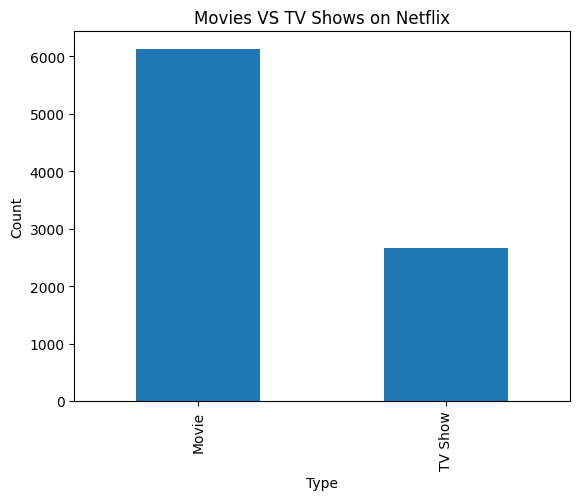

In [23]:
type = df['type'].value_counts().plot(kind = 'bar')
plt.title("Movies VS TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

**2. Content Added Over Years**

*-> What the chart shows:*

This line chart displays the number of titles added to Netflix each year.

*-> Insight:*

Content growth increased rapidly after 2015.

The platform saw peak additions around 2019–2020.

This shows Netflix expanded aggressively during this period.

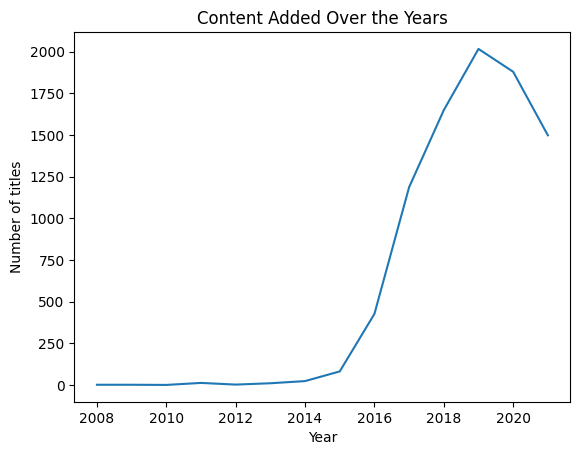

In [24]:
df['year_added'].value_counts().sort_index().plot(kind = 'line')
plt.title("Content Added Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of titles")
plt.show()

**3. Top Producing Countries**

*-> What the chart shows:*

This bar chart shows the top 10 countries contributing the most content to Netflix.

*-> Insight:*

United States produces the highest number of titles.

India is also among the top contributors.

Netflix content is globally diverse.

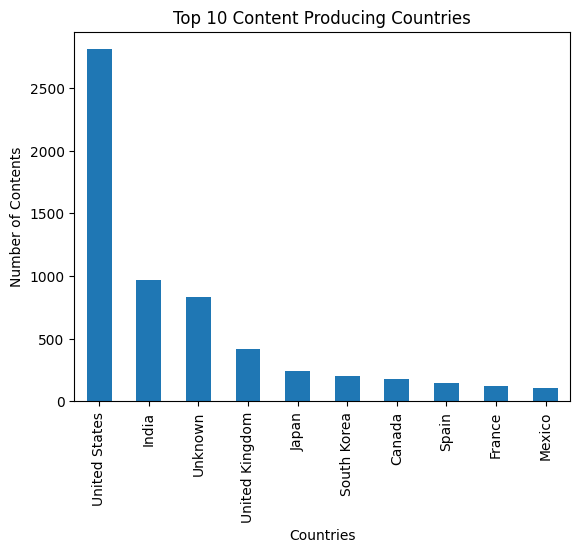

In [25]:
df['country'].value_counts().head(10).plot(kind = 'bar')
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Countries")
plt.ylabel("Number of Contents")
plt.show()

**4. Ratings Distribution**

*-> What the chart shows:*

This chart represents the distribution of content ratings on Netflix.

*-> Insight:*

TV-MA and TV-14 are the most common ratings.

Netflix primarily targets mature and teenage audiences.

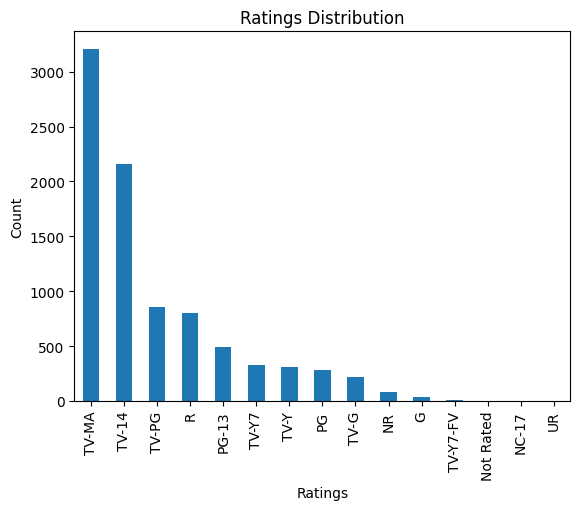

In [26]:
df['rating'].value_counts().plot(kind = 'bar')
plt.title("Ratings Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

**5. Duration Analysis (Movies Only)**

*-> What the chart shows:*

This histogram shows how movie durations are distributed across different time ranges.

*-> Insight:*

Most movies fall between 80 to 120 minutes.

Very few movies exceed 180 minutes.

Netflix prefers standard-length films.

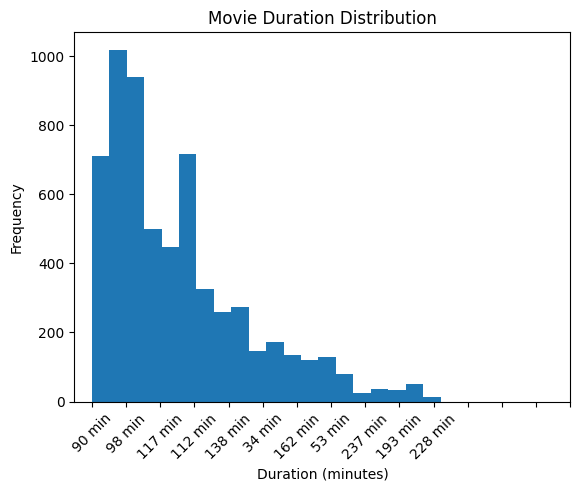

In [27]:
movies = df[df['type'] == 'Movie']

plt.hist(movies['duration'], bins = 20)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.xticks(rotation = 45)
plt.xticks(range(0, 300, 20))
plt.show()

**6. Genre Analysis**

*-> What the chart shows:*

This bar chart displays the top 10 most common genres on Netflix.

*-> Insight:*

Drama is one of the most dominant genres.

International Movies are also highly popular.

Netflix provides diverse genre content.

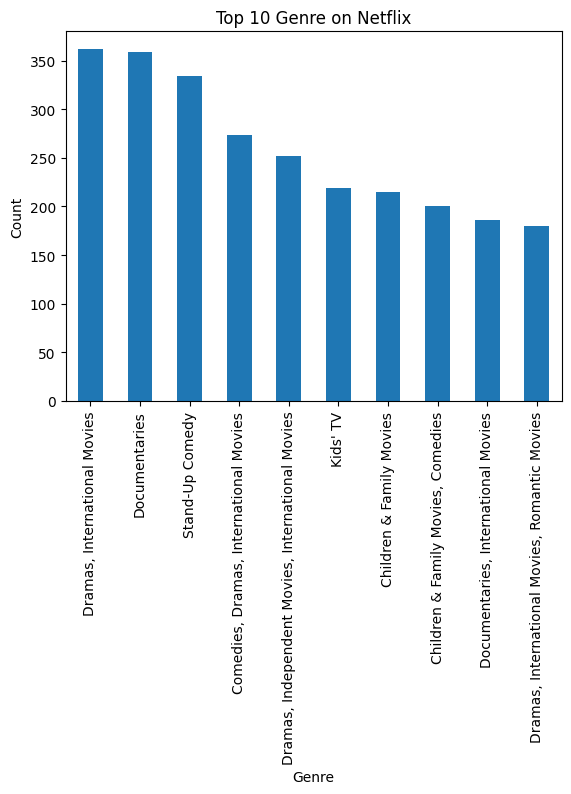

In [28]:
df['listed_in'].value_counts().head(10).plot(kind = 'bar')
plt.title("Top 10 Genre on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

In [29]:
df.to_excel("netflix_cleaned.xlsx", index=False)

## Conclusion

From the analysis of Netflix dataset, the following insights were observed:

-> Netflix has more Movies than TV Shows.

-> Content increased significantly after 2015.

-> USA and India contribute the highest content.

-> TV-MA and TV-14 are most common ratings.

-> Most movies have duration between 80–120 minutes.

-> Drama is one of the most popular genres.

This analysis helps in understanding content trends and audience focus on Netflix.